# LSTM Model

This notebook prepares daily electricity data for multiple NMIs, builds and assesses a next-day LSTM model, and compares selected hyperparameter combinations using chronological validation.

## 1. Imports and settings

Import the required libraries and set the random seed and default sequence length.

In [24]:
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_SEED = 123
LOOKBACK = 14  # Number of past days used to predict the next day.

# Use the same starting random values whenever the notebook is rerun.
np.random.seed(RANDOM_SEED)

## 2. Load data

Load the daily NMI dataset and define the columns used for dates, NMI identity, and the prediction target.

In [25]:
# Dataset location and the three columns used throughout the notebook.
DATA_PATH = Path("nmi_daily_preprocessing.csv")
DATE_COLUMN = "date"
NMI_COLUMN = "NMI"
TARGET_COLUMN = "daily_consumption_raw"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

# Read NMI as text so identifiers are not treated as numerical measurements.
df = pd.read_csv(DATA_PATH, dtype={NMI_COLUMN: "string"}, low_memory=False)

print(f"Loaded {len(df):,} rows and {df.shape[1]} columns.")
print("Columns:", df.columns.tolist())
df.head()

Loaded 415,380 rows and 29 columns.
Columns: ['NMI', 'date', 'building_type', 'building_type_group', 'building_type_count', 'dayofweek', 'month', 'quarter', 'is_weekend', 'trend_days', 'maxtemp', 'mintemp', 'avgtemp', 'temp_range', 'rainfall', 'rain_flag', 'has_solar', 'solar_meter_count_selected', 'solar_radiation_available', 'daily_solar_generation_observed', 'lag_1_day', 'lag_7_day', 'hdd', 'cdd', 'daily_consumption_raw', 'half_hour_reading_count', 'half_hour_zero_count', 'daily_complete_48', 'model_ready_weather_lag']


,NMI,date,building_type,building_type_group,building_type_count,dayofweek,month,quarter,is_weekend,trend_days,...,daily_solar_generation_observed,lag_1_day,lag_7_day,hdd,cdd,daily_consumption_raw,half_hour_reading_count,half_hour_zero_count,daily_complete_48,model_ready_weather_lag
0,6102000812,2013-01-01,Unknown,Unknown,0,1,1,1,0,0,...,NaN,NaN,NaN,NaN,NaN,974.544,48,0,True,False
1,6102000812,2013-01-02,Unknown,Unknown,0,2,1,1,0,1,...,NaN,974.544,NaN,NaN,NaN,1131.152,48,0,True,False
2,6102000812,2013-01-03,Unknown,Unknown,0,3,1,1,0,2,...,NaN,1131.152,NaN,NaN,NaN,1418.752,48,0,True,False
3,6102000812,2013-01-04,Unknown,Unknown,0,4,1,1,0,3,...,NaN,1418.752,NaN,NaN,NaN,1671.390,48,0,True,False
4,6102000812,2013-01-05,Unknown,Unknown,0,5,1,1,1,4,...,NaN,1671.390,NaN,NaN,NaN,1136.448,48,0,True,False


## 3. Data preparation

Select the model inputs, convert the date column, sort each NMI chronologically, and check the required columns, missing values, and duplicate NMI-date rows. Calendar categories are converted to cyclical sine and cosine features later during preprocessing.

In [26]:
# Numerical inputs, including past consumption and weather measurements.
continuous_features = [
    TARGET_COLUMN,
    "maxtemp",
    "mintemp",
    "avgtemp",
    "rainfall",
    "hdd",
    "cdd",
    "lag_1_day",
    "lag_7_day"
]

# Calendar numbers will be converted to sine/cosine pairs below.
calendar_features = [
    "dayofweek",
    "month",
    "quarter",
]

# A binary feature is already represented as 0 or 1.
binary_features = [
    "is_weekend",
]

# Building type will be converted to one-hot columns.
categorical_features = [
    "building_type"
]

# Check that all required columns are present in the dataframe
required_columns = {
    DATE_COLUMN, NMI_COLUMN, TARGET_COLUMN,
    *categorical_features, *continuous_features, *calendar_features, *binary_features
}
missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise KeyError(f"Required columns are missing: {sorted(missing_columns)}")

# Convert dates once and keep every NMI in chronological order.
df[DATE_COLUMN] = pd.to_datetime(df[DATE_COLUMN], errors="raise")
df = df.sort_values([NMI_COLUMN, DATE_COLUMN]).reset_index(drop=True)

columns_needed = [
    NMI_COLUMN, DATE_COLUMN, *categorical_features, *continuous_features,
    *calendar_features, *binary_features
]
missing_value_counts = df[columns_needed].isna().sum()
missing_value_counts = missing_value_counts[missing_value_counts > 0]
if not missing_value_counts.empty:
    print("Columns with missing values (affected sequences will be skipped):")
    display(missing_value_counts.to_frame("missing_rows"))
if df.duplicated([NMI_COLUMN, DATE_COLUMN]).any():
    raise ValueError("Duplicate NMI/date rows were found.")


def add_cyclical_calendar_features(data):
    """Return a copy with calendar cycles represented by sine/cosine pairs."""
    result = data.copy()
    # Sine and cosine keep the end and start of each cycle close together.
    result["dayofweek_sin"] = np.sin(2 * np.pi * result["dayofweek"] / 7)
    result["dayofweek_cos"] = np.cos(2 * np.pi * result["dayofweek"] / 7)
    result["month_sin"] = np.sin(2 * np.pi * (result["month"] - 1) / 12)
    result["month_cos"] = np.cos(2 * np.pi * (result["month"] - 1) / 12)
    result["quarter_sin"] = np.sin(2 * np.pi * (result["quarter"] - 1) / 4)
    result["quarter_cos"] = np.cos(2 * np.pi * (result["quarter"] - 1) / 4)
    return result


cyclic_feature_columns = [
    "dayofweek_sin", "dayofweek_cos",
    "month_sin", "month_cos",
    "quarter_sin", "quarter_cos",
]

print(f"NMIs: {df[NMI_COLUMN].nunique():,}")
print(f"Date range: {df[DATE_COLUMN].min().date()} to {df[DATE_COLUMN].max().date()}")
print("Continuous features to scale:", continuous_features)
print("Categorical features to one-hot encode:", categorical_features)
print("Cyclical calendar features:", cyclic_feature_columns)
print("Binary features kept unchanged:", binary_features)

Columns with missing values (affected sequences will be skipped):


,missing_rows
daily_consumption_raw,74080
maxtemp,12352
mintemp,12157
avgtemp,12449
rainfall,11929
hdd,12449
cdd,12449
lag_1_day,74166
lag_7_day,74682


NMIs: 86
Date range: 2013-01-01 to 2026-03-23
Continuous features to scale: ['daily_consumption_raw', 'maxtemp', 'mintemp', 'avgtemp', 'rainfall', 'hdd', 'cdd', 'lag_1_day', 'lag_7_day']
Categorical features to one-hot encode: ['building_type']
Cyclical calendar features: ['dayofweek_sin', 'dayofweek_cos', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos']
Binary features kept unchanged: ['is_weekend']


## 4. Train / validation / test split

Assign every row to a manually selected training, validation, or test period. The split is chronological, uses the same dates for every NMI, and excludes dates outside the selected periods.

In [27]:
# Change these dates when a different chronological split is required.
TRAIN_START_DATE = "2014-01-01"
TRAIN_END_DATE = "2019-12-31"

VALIDATION_START_DATE = "2022-01-01"
VALIDATION_END_DATE = "2023-12-31"

TEST_START_DATE = "2024-01-01"
TEST_END_DATE = "2025-12-31"

# Convert text dates into pandas timestamps for filtering and comparison.
train_start = pd.Timestamp(TRAIN_START_DATE)
train_end = pd.Timestamp(TRAIN_END_DATE)
validation_start = pd.Timestamp(VALIDATION_START_DATE)
validation_end = pd.Timestamp(VALIDATION_END_DATE)
test_start = pd.Timestamp(TEST_START_DATE)
test_end = pd.Timestamp(TEST_END_DATE)

if not (
    train_start <= train_end
    < validation_start <= validation_end
    < test_start <= test_end
):
    raise ValueError(
        "Date ranges must be ordered: train, then validation, then test."
    )

# Each mask is True for rows that fall inside that period.
train_row_mask = df[DATE_COLUMN].between(train_start, train_end, inclusive="both")
validation_row_mask = df[DATE_COLUMN].between(
    validation_start, validation_end, inclusive="both"
)
test_row_mask = df[DATE_COLUMN].between(test_start, test_end, inclusive="both")

# Keep only rows in one of the manually selected periods.
df = df.loc[train_row_mask | validation_row_mask | test_row_mask].copy()
# Store the split name on each retained row for sequence creation.
df["split"] = np.select(
    [
        df[DATE_COLUMN].between(train_start, train_end, inclusive="both"),
        df[DATE_COLUMN].between(validation_start, validation_end, inclusive="both"),
    ],
    ["train", "validation"],
    default="test",
)

train_df = df.loc[df["split"] == "train"].copy()
validation_df = df.loc[df["split"] == "validation"].copy()
test_df = df.loc[df["split"] == "test"].copy()

if train_df[DATE_COLUMN].nunique() <= LOOKBACK:
    raise ValueError("The selected training period must be longer than LOOKBACK.")
if validation_df.empty or test_df.empty:
    raise ValueError("The selected validation and test periods must not be empty.")

print(f"Train:      {train_df[DATE_COLUMN].min().date()} to {train_df[DATE_COLUMN].max().date()} ({len(train_df):,} rows)")
print(f"Validation: {validation_df[DATE_COLUMN].min().date()} to {validation_df[DATE_COLUMN].max().date()} ({len(validation_df):,} rows)")
print(f"Test:       {test_df[DATE_COLUMN].min().date()} to {test_df[DATE_COLUMN].max().date()} ({len(test_df):,} rows)")

Train:      2014-01-01 to 2019-12-31 (188,426 rows)
Validation: 2022-01-01 to 2023-12-31 (62,780 rows)
Test:       2024-01-01 to 2025-12-31 (62,866 rows)


## 5. Scaling

Fit scaling and one-hot encoding on training rows only, then apply the fitted transformations to every split. Continuous variables are standardized, building type is one-hot encoded, calendar variables become cyclical features, and the weekend indicator is kept unchanged. NMI identity is handled separately.

In [28]:
def fit_preprocessors(training_data):
    """Fit every learned preprocessing object on training rows only."""
    # StandardScaler places numerical variables on comparable scales.
    fitted_continuous_scaler = StandardScaler()
    fitted_onehot_encoder = OneHotEncoder(
        handle_unknown="ignore", sparse_output=False
    )
    fitted_target_scaler = StandardScaler()

    fitted_continuous_scaler.fit(training_data[continuous_features])
    fitted_onehot_encoder.fit(training_data[categorical_features])
    fitted_target_scaler.fit(training_data[[TARGET_COLUMN]])
    return fitted_continuous_scaler, fitted_onehot_encoder, fitted_target_scaler


# Fit once on the main training period; validation and test do not affect it.
continuous_scaler, onehot_encoder, target_scaler = fit_preprocessors(train_df)
scaled_continuous_columns = [
    f"scaled__{column}" for column in continuous_features
]
onehot_feature_columns = onehot_encoder.get_feature_names_out(
    categorical_features
).tolist()
# This ordered list defines the feature axis of every LSTM sequence.
model_feature_columns = (
    scaled_continuous_columns
    + onehot_feature_columns
    + cyclic_feature_columns
    + binary_features
)


def transform_model_features(
    data, fitted_scaler, fitted_encoder, encoded_feature_columns
):
    """Apply fitted preprocessing while retaining raw columns for later use."""
    # Work on a copy so the original columns remain available for tuning.
    transformed = add_cyclical_calendar_features(data)
    transformed[scaled_continuous_columns] = fitted_scaler.transform(
        transformed[continuous_features]
    )
    transformed[encoded_feature_columns] = fitted_encoder.transform(
        transformed[categorical_features]
    )
    return transformed


df = transform_model_features(
    df, continuous_scaler, onehot_encoder, onehot_feature_columns
)
df["target_scaled"] = target_scaler.transform(df[[TARGET_COLUMN]]).ravel()

print("All learned preprocessors were fitted on training rows only.")
print(f"Final number of time-series features: {len(model_feature_columns)}")
print("Time-series features:", model_feature_columns)

All learned preprocessors were fitted on training rows only.
Final number of time-series features: 29
Time-series features: ['scaled__daily_consumption_raw', 'scaled__maxtemp', 'scaled__mintemp', 'scaled__avgtemp', 'scaled__rainfall', 'scaled__hdd', 'scaled__cdd', 'scaled__lag_1_day', 'scaled__lag_7_day', 'building_type_Building - Clinical', 'building_type_Building - Commercial', 'building_type_Building - Commercial; Building - Highly Serviced / Wet Lab; Building - Minimal/Infra- Shed/Whse/Bulk Store/Spo', 'building_type_Building - Commercial; Building - Highly Serviced / Wet Lab; Building - Minimal/Infra- Shed/Whse/Bulk Store/Spo; Building - Workspace/Teaching/Library', 'building_type_Building - Commercial; Building - Highly Serviced / Wet Lab; Building - Workspace/Teaching/Library', 'building_type_Building - Commercial; Building - Minimal/Infra- Shed/Whse/Bulk Store/Spo', 'building_type_Building - Highly Serviced / Wet Lab', 'building_type_Building - Highly Serviced / Wet Lab; Buildi

## 6. Sequence creation

Convert the table into the 3D input required by an LSTM: `(samples, lookback, features)`. Each sequence contains `LOOKBACK` consecutive days from one NMI and predicts that NMI's consumption on the next day. With `LOOKBACK = 30`:

- Day 1–30 → Day 31
- Day 2–31 → Day 32

Sequences are created separately for each NMI and uninterrupted daily block. A matching integer NMI index is created for every sequence. Index 0 is reserved for an NMI that has no valid training sequence and will receive the neutral fallback embedding.

In [29]:
def create_sequences(data, input_columns, lookback, stride=1, verbose=True):
    """Create per-NMI windows; stride=1 keeps every possible target day."""
    # Each list collects one item for every valid prediction example.
    X_sequences = []
    y_sequences = []
    sequence_splits = []
    sequence_nmis = []
    target_dates = []
    skipped_sequences = 0

    for nmi, nmi_data in data.groupby(NMI_COLUMN, sort=False):
        nmi_data = nmi_data.sort_values(DATE_COLUMN).copy()

        # Never let a sequence cross a gap in this NMI's daily history.
        new_block = nmi_data[DATE_COLUMN].diff().ne(pd.Timedelta(days=1))
        nmi_data["contiguous_block"] = new_block.cumsum()

        for _, block in nmi_data.groupby("contiguous_block", sort=False):
            block = block.reset_index(drop=True)
            feature_values = block[input_columns].to_numpy(dtype=np.float32)
            target_values = block["target_scaled"].to_numpy(dtype=np.float32)

            # target_index is the day being predicted; earlier rows form X.
            for target_index in range(lookback, len(block), stride):
                window_start = target_index - lookback

                # Temporary handling for the older dataset version.
                if (
                    not np.isfinite(feature_values[window_start:target_index]).all()
                    or not np.isfinite(target_values[target_index])
                ):
                    skipped_sequences += 1
                    continue

                X_sequences.append(feature_values[window_start:target_index])
                y_sequences.append(target_values[target_index])
                sequence_splits.append(block.loc[target_index, "split"])
                sequence_nmis.append(nmi)
                target_dates.append(block.loc[target_index, DATE_COLUMN])

    if not X_sequences:
        raise ValueError("No sequences were created. Reduce LOOKBACK or inspect the data.")
    if verbose:
        print(f"Skipped {skipped_sequences:,} sequences with non-finite values.")

    return (
        np.asarray(X_sequences, dtype=np.float32),
        np.asarray(y_sequences, dtype=np.float32),
        np.asarray(sequence_splits),
        np.asarray(sequence_nmis),
        np.asarray(target_dates),
    )

# X_all has shape (samples, lookback, features); y_all has one target per sample.
X_all, y_all, sequence_splits, sequence_nmis, target_dates = create_sequences(
    data=df,
    input_columns=model_feature_columns,
    lookback=LOOKBACK,
)

# Use the target day's split label to separate the completed sequences.
train_sequence_mask = sequence_splits == "train"
validation_sequence_mask = sequence_splits == "validation"
test_sequence_mask = sequence_splits == "test"

X_train, y_train = X_all[train_sequence_mask], y_all[train_sequence_mask]
X_validation, y_validation = (
    X_all[validation_sequence_mask], y_all[validation_sequence_mask]
)
X_test, y_test = X_all[test_sequence_mask], y_all[test_sequence_mask]

# Build the embedding vocabulary only from NMIs with valid training sequences.
COLD_START_NMI_INDEX = 0


def build_nmi_index_data(nmi_values, training_mask):
    """Create one shared NMI vocabulary and aligned integer indices."""
    # Known training NMIs receive indices 1, 2, 3, and so on.
    known_training_nmis = sorted({
        str(nmi) for nmi in nmi_values[training_mask]
    })
    nmi_lookup = {
        nmi: index + 1 for index, nmi in enumerate(known_training_nmis)
    }
    # An NMI absent from valid training sequences receives fallback index 0.
    all_indices = np.asarray([
        nmi_lookup.get(str(nmi), COLD_START_NMI_INDEX)
        for nmi in nmi_values
    ], dtype=np.int32)

    if (all_indices[training_mask] == COLD_START_NMI_INDEX).any():
        raise ValueError("A training sequence received the cold-start NMI index.")

    return {
        "training_nmis": known_training_nmis,
        "nmi_to_index": nmi_lookup,
        "all_indices": all_indices,
        "vocabulary_size": len(nmi_lookup) + 1,
    }


nmi_index_data = build_nmi_index_data(sequence_nmis, train_sequence_mask)
training_nmis = nmi_index_data["training_nmis"]
nmi_to_index = nmi_index_data["nmi_to_index"]
NMI_VOCABULARY_SIZE = nmi_index_data["vocabulary_size"]
sequence_nmi_indices = nmi_index_data["all_indices"]
# Every X sample now has one matching integer NMI input.
nmi_train = sequence_nmi_indices[train_sequence_mask].reshape(-1, 1)
nmi_validation = sequence_nmi_indices[validation_sequence_mask].reshape(-1, 1)
nmi_test = sequence_nmi_indices[test_sequence_mask].reshape(-1, 1)

print(f"Train X shape: {X_train.shape}; y shape: {y_train.shape}")
print(f"Validation X shape: {X_validation.shape}; y shape: {y_validation.shape}")
print(f"Test X shape: {X_test.shape}; y shape: {y_test.shape}")
print(f"Train NMI input shape: {nmi_train.shape}")
print(f"Validation NMI input shape: {nmi_validation.shape}")
print(f"Test NMI input shape: {nmi_test.shape}")
print(f"Learned NMI-specific embedding rows: {len(training_nmis)}")
print("Cold-start NMI embedding: index 0 (neutral zero vector; unused in training)")
print(f"Validation cold-start sequences: {(nmi_validation == COLD_START_NMI_INDEX).sum():,}")
print(f"Test cold-start sequences: {(nmi_test == COLD_START_NMI_INDEX).sum():,}")

Skipped 56,292 sequences with non-finite values.
Train X shape: (132755, 14, 29); y shape: (132755,)
Validation X shape: (61090, 14, 29); y shape: (61090,)
Test X shape: (61527, 14, 29); y shape: (61527,)
Train NMI input shape: (132755, 1)
Validation NMI input shape: (61090, 1)
Test NMI input shape: (61527, 1)
Learned NMI-specific embedding rows: 75
Cold-start NMI embedding: index 0 (neutral zero vector; unused in training)
Validation cold-start sequences: 7,576
Test cold-start sequences: 7,891


## 7. Build the LSTM model

Build a model with two inputs: the daily feature sequence and its NMI index. The embedding layer converts the NMI index into a short learned vector. This vector is added to every day in the sequence before the data enters one or two LSTM layers.

In [30]:
# Default model settings used before hyperparameter tuning.
LSTM_UNITS = 64
NUMBER_OF_LSTM_LAYERS = 1
DROPOUT = 0.0
LEARNING_RATE = 0.001
BATCH_SIZE = 256
MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 5
NMI_EMBEDDING_DIM = 4


def build_lstm_model(
    sequence_shape, nmi_vocabulary_size, lstm_units, dropout,
    embedding_dim, learning_rate, number_of_lstm_layers=1
):
    """Build a small two-input model for sequences and NMI IDs."""
    # Keras requires native Python integers, not NumPy integer scalars.
    nmi_vocabulary_size = int(nmi_vocabulary_size)
    lstm_units = int(lstm_units)
    embedding_dim = int(embedding_dim)
    number_of_lstm_layers = int(number_of_lstm_layers)
    # sequence_input receives (lookback, features) for each sample.
    sequence_input = tf.keras.layers.Input(
        shape=sequence_shape, name="sequence_input"
    )
    # nmi_input receives one integer NMI index for the same sample.
    nmi_input = tf.keras.layers.Input(
        shape=(1,), dtype="int32", name="nmi_input"
    )

    # Known NMIs start randomly; the cold-start row starts at exactly zero.
    embedding_values = np.random.default_rng(RANDOM_SEED).uniform(
        low=-0.05, high=0.05, size=(nmi_vocabulary_size, embedding_dim)
    ).astype(np.float32)
    embedding_values[COLD_START_NMI_INDEX] = 0.0

    # The cold-start index is absent from training, so it remains a zero vector.
    nmi_embedding = tf.keras.layers.Embedding(
        input_dim=nmi_vocabulary_size,
        output_dim=embedding_dim,
        embeddings_initializer=tf.keras.initializers.Constant(embedding_values),
        name="nmi_embedding",
    )(nmi_input)
    nmi_embedding = tf.keras.layers.Flatten()(nmi_embedding)

    # NMI is static, so repeat the same embedding for every day in the window.
    repeated_nmi_embedding = tf.keras.layers.RepeatVector(
        sequence_shape[0], name="repeat_nmi_embedding"
    )(nmi_embedding)
    combined_sequence = tf.keras.layers.Concatenate(
        axis=-1, name="sequence_with_nmi"
    )([sequence_input, repeated_nmi_embedding])

    # A two-layer model must return the full sequence from its first layer.
    if number_of_lstm_layers == 1:
        sequence_representation = tf.keras.layers.LSTM(
            lstm_units, dropout=dropout, name="lstm_1"
        )(combined_sequence)
    elif number_of_lstm_layers == 2:
        first_lstm_output = tf.keras.layers.LSTM(
            lstm_units, dropout=dropout, return_sequences=True, name="lstm_1"
        )(combined_sequence)
        sequence_representation = tf.keras.layers.LSTM(
            lstm_units, dropout=dropout, name="lstm_2"
        )(first_lstm_output)
    else:
        raise ValueError("number_of_lstm_layers must be 1 or 2.")
    output = tf.keras.layers.Dense(
        1, name="consumption_output"
    )(sequence_representation)

    embedding_model = tf.keras.Model(
        inputs={
            "sequence_input": sequence_input,
            "nmi_input": nmi_input,
        },
        outputs=output,
    )
    embedding_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mean_squared_error",
    )
    return embedding_model


def make_model_inputs(sequence_values, nmi_values):
    """Keep the two model inputs aligned and consistently named."""
    return {
        "sequence_input": sequence_values,
        "nmi_input": nmi_values,
    }


tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_SEED)
model = build_lstm_model(
    sequence_shape=X_train.shape[1:],
    nmi_vocabulary_size=NMI_VOCABULARY_SIZE,
    lstm_units=LSTM_UNITS,
    dropout=DROPOUT,
    embedding_dim=NMI_EMBEDDING_DIM,
    learning_rate=LEARNING_RATE,
    number_of_lstm_layers=NUMBER_OF_LSTM_LAYERS,
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ nmi_input           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nmi_embedding       │ (None, 1, 4)      │        304 │ nmi_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 4)         │          0 │ nmi_embedding[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_input      │ (None, 14, 29)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_nmi_embeddi… │ (None, 14, 4)     │          0 │ flatten[0][0]     │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequence_with_nmi   │ (None, 14, 33)    │          0 │ sequence_input[0… │
│ (Concatenate)       │                   │            │ repeat_nmi_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     25,088 │ sequence_with_nm… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ consumption_output  │ (None, 1)         │         65 │ lstm_1[0][0]      │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,457 (99.44 KB)

 Trainable params: 25,457 (99.44 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the model

Train the model without shuffling the sequences. Validation loss controls early stopping, and the weights from the best epoch are restored.

In [31]:
# Stop when validation loss no longer improves and keep the best weights.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOPPING_PATIENCE,
    min_delta=0.001,
    restore_best_weights=True,
)

# Every known training NMI keeps its own ID; no IDs are randomly masked.
train_inputs = make_model_inputs(X_train, nmi_train)
validation_inputs = make_model_inputs(X_validation, nmi_validation)

# history stores the training and validation loss from every completed epoch.
history = model.fit(
    train_inputs,
    y_train,
    validation_data=(validation_inputs, y_validation),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping],
    shuffle=False,
    verbose=1,
)

epochs_completed = len(history.history["loss"])
best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_validation_loss = float(np.min(history.history["val_loss"]))

print(f"Training stopped after epoch {epochs_completed}.")
print(f"Best epoch: {best_epoch}")
print(f"Best validation loss: {best_validation_loss:.6f}")

# Confirm that the cold-start embedding remained a neutral zero vector.
embedding_weights = model.get_layer("nmi_embedding").get_weights()[0]
cold_start_embedding = embedding_weights[COLD_START_NMI_INDEX]
if not np.allclose(cold_start_embedding, 0.0):
    raise ValueError("The cold-start NMI embedding changed during training.")
print(f"Cold-start embedding norm: {np.linalg.norm(cold_start_embedding):.6f}")

Epoch 1/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0725 - val_loss: 0.0406
Epoch 2/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0244 - val_loss: 0.0258
Epoch 3/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0191 - val_loss: 0.0184
Epoch 4/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0174 - val_loss: 0.0162
Epoch 5/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0151 - val_loss: 0.0106
Epoch 6/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.0141 - val_loss: 0.0119
Epoch 7/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - loss: 0.0167 - val_loss: 0.0134
Epoch 8/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0128 - val_loss: 0.0101
Epoch 9/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 0.0111 - val_loss: 0.0086
Epoch 10/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0105 - val_loss: 0.0103
Epoch 11/30
519/519 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.0108 - val_loss: 0.0123
Epoch 12/30
519/519 ━━━━━━━━━━━━━━━

## 9. Training diagnostics

Plot training and validation loss for each epoch and mark the epoch with the lowest validation loss.

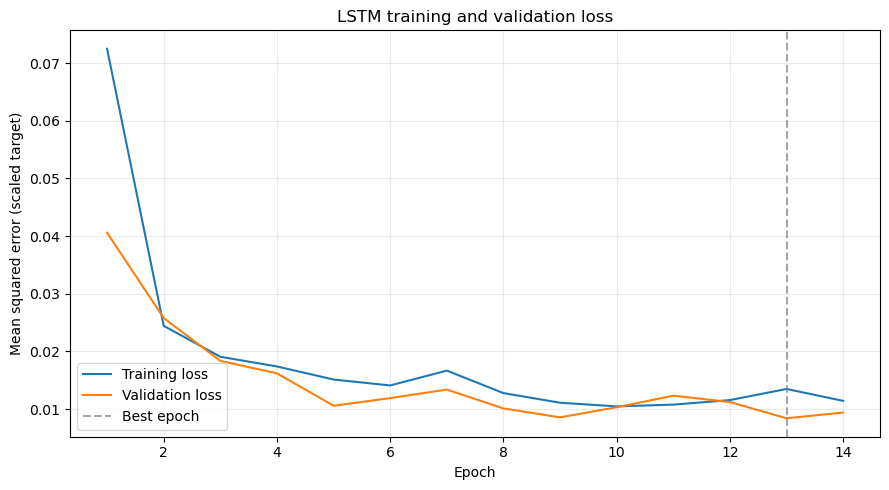

In [32]:
# Compare the two loss curves to identify convergence or overfitting.
plt.figure(figsize=(9, 5))
epochs = range(1, len(history.history["loss"]) + 1)
plt.plot(epochs, history.history["loss"], label="Training loss")
plt.plot(epochs, history.history["val_loss"], label="Validation loss")
plt.axvline(best_epoch, color="grey", linestyle="--", alpha=0.7, label="Best epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean squared error (scaled target)")
plt.title("LSTM training and validation loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Model assessment

Convert predictions back to the original consumption units and calculate MAE, RMSE, and WAPE. Keep the NMI and target date so performance can also be summarized at daily, yearly, NMI, and total-site levels.

In [33]:
def inverse_target(values):
    """Convert scaled targets back to daily-consumption units."""
    values = np.asarray(values).reshape(-1, 1)
    return target_scaler.inverse_transform(values).ravel()


def regression_metrics(actual, predicted):
    """Calculate metrics in the original target units."""
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    absolute_actual_total = np.abs(actual).sum()
    wape = (
        np.abs(actual - predicted).sum() / absolute_actual_total * 100
        if absolute_actual_total > 0 else np.nan
    )
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "WAPE": wape,
    }


def create_prediction_results(
    split_name, X_values, nmi_values, y_values, sequence_mask
):
    """Predict one split and retain its NMI/date mapping."""
    predictions_scaled = model.predict(
        make_model_inputs(X_values, nmi_values),
        batch_size=BATCH_SIZE,
        verbose=0,
    ).ravel()
    return pd.DataFrame({
        NMI_COLUMN: sequence_nmis[sequence_mask],
        "target_date": pd.to_datetime(target_dates[sequence_mask]),
        "actual_consumption": inverse_target(y_values),
        "predicted_consumption": inverse_target(predictions_scaled),
        "split": split_name,
    })


# Generate one row per validation or test sequence.
validation_results = create_prediction_results(
    "validation", X_validation, nmi_validation, y_validation,
    validation_sequence_mask,
)
test_results = create_prediction_results(
    "test", X_test, nmi_test, y_test, test_sequence_mask
)
prediction_results = pd.concat(
    [validation_results, test_results], ignore_index=True
)

# Calculate overall metrics separately for validation and test data.
assessment_metrics = pd.DataFrame([
    {"split": split_name, **regression_metrics(
        split_results["actual_consumption"],
        split_results["predicted_consumption"],
    )}
    for split_name, split_results in {
        "validation": validation_results,
        "test": test_results,
    }.items()
])

# Aggregate test results to inspect NMI-level and portfolio-level performance.
test_results["year"] = test_results["target_date"].dt.year
test_levels = {
    "Per-NMI daily": test_results,
    "Per-NMI yearly": test_results.groupby(
        [NMI_COLUMN, "year"], as_index=False
    )[["actual_consumption", "predicted_consumption"]].sum(),
    "Total-site daily": test_results.groupby(
        "target_date", as_index=False
    )[["actual_consumption", "predicted_consumption"]].sum(),
    "Total-site yearly": test_results.groupby(
        "year", as_index=False
    )[["actual_consumption", "predicted_consumption"]].sum(),
}
test_level_metrics = pd.DataFrame([
    {"level": level, **regression_metrics(
        level_data["actual_consumption"],
        level_data["predicted_consumption"],
    )}
    for level, level_data in test_levels.items()
])

display(assessment_metrics.round(3))
display(test_level_metrics.round(3))
display(prediction_results.head())

,split,MAE,RMSE,WAPE
0,validation,339.698,498.270,9.736
1,test,355.588,525.464,9.896


,level,MAE,RMSE,WAPE
0,Per-NMI daily,355.588,525.464,9.896
1,Per-NMI yearly,51199.004,66546.114,3.983
2,Total-site daily,16502.605,21079.432,5.456
3,Total-site yearly,192048.000,223797.595,0.174


,NMI,target_date,actual_consumption,predicted_consumption,split
0,6102000812,2022-01-15,843.135864,688.932251,validation
1,6102000812,2022-01-16,906.207886,499.824341,validation
2,6102000812,2022-01-17,1007.263794,1234.442749,validation
3,6102000812,2022-01-18,1037.216187,1000.753052,validation
4,6102000812,2022-01-19,1052.735962,849.190796,validation


## 11. Hyperparameter tuning

Test every selected hyperparameter combination using expanding chronological folds. Training starts with 2022 data, while 2023 is divided into two or three validation blocks. Each later fold adds the earlier validation block to its training data. To reduce runtime, tuning keeps every third possible sequence. The 2024–2025 test period is excluded.

In [22]:
# Short, recent periods for the initial hyperparameter search.
TUNING_TRAIN_START_DATE = "2022-01-01"
TUNING_TRAIN_END_DATE = "2022-12-31"
TUNING_VALIDATION_START_DATE = "2023-01-01"
TUNING_VALIDATION_END_DATE = "2023-12-31"

# The full grid will test every combination of the values below.
TUNING_LOOKBACKS = [14, 30]
TUNING_LSTM_LAYERS = [1, 2]
TUNING_LSTM_UNITS = [32, 64]
TUNING_DROPOUTS = [0.0, 0.1, 0.2]
TUNING_EMBEDDING_DIMS = [4, 8]
NUMBER_OF_TIME_FOLDS = 3  # Use either 2 or 3.
TUNING_SEQUENCE_STRIDE = 3
TUNING_MAX_EPOCHS = 12
TUNING_PATIENCE = 3

tuning_train_start = pd.Timestamp(TUNING_TRAIN_START_DATE)
tuning_train_end = pd.Timestamp(TUNING_TRAIN_END_DATE)
tuning_validation_start = pd.Timestamp(TUNING_VALIDATION_START_DATE)
tuning_validation_end = pd.Timestamp(TUNING_VALIDATION_END_DATE)

if not (
    tuning_train_start <= tuning_train_end
    < tuning_validation_start <= tuning_validation_end
    < test_start
):
    raise ValueError("Tuning dates must be chronological and end before testing.")

if NUMBER_OF_TIME_FOLDS not in (2, 3):
    raise ValueError("NUMBER_OF_TIME_FOLDS must be 2 or 3.")

# Work only with the short development window; no test rows enter tuning.
tuning_data = df.loc[df[DATE_COLUMN].between(
    tuning_train_start, tuning_validation_end, inclusive="both"
)].copy()
initial_tuning_train_rows = tuning_data[DATE_COLUMN].between(
    tuning_train_start, tuning_train_end, inclusive="both"
)
all_tuning_validation_rows = tuning_data[DATE_COLUMN].between(
    tuning_validation_start, tuning_validation_end, inclusive="both"
)

if not initial_tuning_train_rows.any() or not all_tuning_validation_rows.any():
    raise ValueError("The selected tuning periods contain no rows.")

# Split 2023 into consecutive blocks. Each later fold adds prior blocks to training.
validation_dates = np.sort(
    tuning_data.loc[all_tuning_validation_rows, DATE_COLUMN].unique()
)
# np.array_split creates consecutive blocks with nearly equal numbers of days.
validation_date_blocks = np.array_split(
    validation_dates, NUMBER_OF_TIME_FOLDS
)
expanding_folds = [
    {
        "fold": fold_number,
        "validation_start": pd.Timestamp(date_block[0]),
        "validation_end": pd.Timestamp(date_block[-1]),
    }
    for fold_number, date_block in enumerate(validation_date_blocks, start=1)
]

fold_summary = pd.DataFrame([
    {
        "fold": fold["fold"],
        "train_start": tuning_train_start,
        "train_end": fold["validation_start"] - pd.Timedelta(days=1),
        "validation_start": fold["validation_start"],
        "validation_end": fold["validation_end"],
    }
    for fold in expanding_folds
])
number_of_configurations = (
    len(TUNING_LOOKBACKS) * len(TUNING_LSTM_LAYERS)
    * len(TUNING_LSTM_UNITS) * len(TUNING_DROPOUTS)
    * len(TUNING_EMBEDDING_DIMS)
)

display(fold_summary)
print(f"Tuning train: {TUNING_TRAIN_START_DATE} to {TUNING_TRAIN_END_DATE}")
print(f"Validation blocks: {NUMBER_OF_TIME_FOLDS} expanding time folds in 2023")
print(f"Tuning sequence stride: {TUNING_SEQUENCE_STRIDE}")
print(f"Full grid: {number_of_configurations} configurations")
print(f"Total model fits: {number_of_configurations * NUMBER_OF_TIME_FOLDS}")

,fold,train_start,train_end,validation_start,validation_end
0,1,2022-01-01,2022-12-31,2023-01-01,2023-05-02
1,2,2022-01-01,2023-05-02,2023-05-03,2023-09-01
2,3,2022-01-01,2023-09-01,2023-09-02,2023-12-31


Tuning train: 2022-01-01 to 2022-12-31
Validation blocks: 3 expanding time folds in 2023
Tuning sequence stride: 3
Full grid: 48 configurations
Total model fits: 144


In [23]:
# Reuse arrays for configurations that share the same fold and lookback.
tuning_sequence_cache = {}


def prepare_tuning_sequences(fold, lookback):
    """Prepare leakage-safe arrays for one fold and lookback value."""
    cache_key = (fold["fold"], lookback)
    if cache_key in tuning_sequence_cache:
        return tuning_sequence_cache[cache_key]

    # Include history only through this fold's validation end.
    prepared_data = tuning_data.loc[
        tuning_data[DATE_COLUMN] <= fold["validation_end"]
    ].copy()
    prepared_train_rows = prepared_data[DATE_COLUMN] < fold["validation_start"]
    prepared_validation_rows = prepared_data[DATE_COLUMN].between(
        fold["validation_start"], fold["validation_end"], inclusive="both"
    )
    prepared_data["split"] = np.select(
        [prepared_train_rows, prepared_validation_rows],
        ["train", "validation"],
        default="unused",
    )

    # Refit every learned transformation on this fold's training rows only.
    tuning_scaler, tuning_encoder, tuning_target_scaler = fit_preprocessors(
        prepared_data.loc[prepared_train_rows]
    )
    tuning_onehot_columns = tuning_encoder.get_feature_names_out(
        categorical_features
    ).tolist()
    prepared_data = transform_model_features(
        prepared_data, tuning_scaler, tuning_encoder, tuning_onehot_columns
    )
    prepared_data["target_scaled"] = tuning_target_scaler.transform(
        prepared_data[[TARGET_COLUMN]]
    ).ravel()
    tuning_feature_columns = (
        scaled_continuous_columns + tuning_onehot_columns
        + cyclic_feature_columns + binary_features
    )

    X_tuning, y_tuning, labels, tuning_nmis, _ = create_sequences(
        prepared_data, tuning_feature_columns, lookback,
        stride=TUNING_SEQUENCE_STRIDE, verbose=False,
    )
    train_mask = labels == "train"
    validation_mask = labels == "validation"

    # Reuse the same NMI-indexing logic as the main sequence workflow.
    fold_nmi_index_data = build_nmi_index_data(tuning_nmis, train_mask)
    tuning_nmi_indices = fold_nmi_index_data["all_indices"]

    # Named arrays make their purpose clear when training each candidate model.
    prepared = {
        "X_train": X_tuning[train_mask],
        "y_train": y_tuning[train_mask],
        "nmi_train": tuning_nmi_indices[train_mask].reshape(-1, 1),
        "X_validation": X_tuning[validation_mask],
        "y_validation": y_tuning[validation_mask],
        "nmi_validation": tuning_nmi_indices[validation_mask].reshape(-1, 1),
        "target_scaler": tuning_target_scaler,
        "nmi_vocabulary_size": fold_nmi_index_data["vocabulary_size"],
    }
    tuning_sequence_cache[cache_key] = prepared
    return prepared


def evaluate_configuration(
    lookback, number_of_lstm_layers, units, dropout, embedding_dim
):
    """Train one candidate across all folds and return fold MAEs."""
    lookback = int(lookback)
    number_of_lstm_layers = int(number_of_lstm_layers)
    units = int(units)
    embedding_dim = int(embedding_dim)
    fold_maes = []

    # The same configuration is rebuilt and assessed independently in each fold.
    for fold in expanding_folds:
        fold_arrays = prepare_tuning_sequences(fold, lookback)

        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(RANDOM_SEED)
        tuning_model = build_lstm_model(
            sequence_shape=fold_arrays["X_train"].shape[1:],
            nmi_vocabulary_size=fold_arrays["nmi_vocabulary_size"],
            lstm_units=units,
            dropout=dropout,
            embedding_dim=embedding_dim,
            learning_rate=LEARNING_RATE,
            number_of_lstm_layers=number_of_lstm_layers,
        )
        stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=TUNING_PATIENCE,
            restore_best_weights=True,
        )
        tuning_model.fit(
            make_model_inputs(
                fold_arrays["X_train"], fold_arrays["nmi_train"]
            ),
            fold_arrays["y_train"],
            validation_data=(
                make_model_inputs(
                    fold_arrays["X_validation"],
                    fold_arrays["nmi_validation"],
                ),
                fold_arrays["y_validation"],
            ),
            epochs=TUNING_MAX_EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[stopping],
            shuffle=False,
            verbose=0,
        )
        predictions_scaled = tuning_model.predict(
            make_model_inputs(
                fold_arrays["X_validation"],
                fold_arrays["nmi_validation"],
            ),
            batch_size=BATCH_SIZE, verbose=0,
        )
        predictions = fold_arrays["target_scaler"].inverse_transform(
            predictions_scaled
        ).ravel()
        actual = fold_arrays["target_scaler"].inverse_transform(
            fold_arrays["y_validation"].reshape(-1, 1)
        ).ravel()
        fold_mae = mean_absolute_error(actual, predictions)
        fold_maes.append(fold_mae)
        print(f"  Fold {fold['fold']} MAE: {fold_mae:.3f}")

    return fold_maes


def run_full_grid_search():
    """Evaluate every hyperparameter combination on every time fold."""
    grid_results = []
    parameter_grid = product(
        TUNING_LOOKBACKS, TUNING_LSTM_LAYERS, TUNING_LSTM_UNITS,
        TUNING_DROPOUTS, TUNING_EMBEDDING_DIMS,
    )

    # Each item from product is one complete hyperparameter configuration.
    for configuration_number, values in enumerate(parameter_grid, start=1):
        lookback, layers, units, dropout, embedding_dim = values
        print(
            f"Configuration {configuration_number}/{number_of_configurations}: "
            f"lookback={lookback}, layers={layers}, units={units}, "
            f"dropout={dropout}, embedding={embedding_dim}"
        )
        fold_maes = evaluate_configuration(
            lookback=lookback,
            number_of_lstm_layers=layers,
            units=units,
            dropout=dropout,
            embedding_dim=embedding_dim,
        )
        result = {
            "lookback": lookback,
            "number_of_lstm_layers": layers,
            "units": units,
            "dropout": dropout,
            "embedding_dim": embedding_dim,
            "mean_validation_mae": np.mean(fold_maes),
            "std_validation_mae": np.std(fold_maes),
        }
        for fold_number, fold_mae in enumerate(fold_maes, start=1):
            result[f"fold_{fold_number}_mae"] = fold_mae
        grid_results.append(result)
        print(f"  Mean MAE: {np.mean(fold_maes):.3f}\n")

    # The best configuration is the one with the lowest average fold MAE.
    return pd.DataFrame(grid_results).sort_values(
        "mean_validation_mae"
    ).reset_index(drop=True)


# Running this cell launches the complete grid search.
tuning_results = run_full_grid_search()
best_result = tuning_results.iloc[0]
best_settings = {
    "lookback": int(best_result["lookback"]),
    "number_of_lstm_layers": int(best_result["number_of_lstm_layers"]),
    "units": int(best_result["units"]),
    "dropout": float(best_result["dropout"]),
    "embedding_dim": int(best_result["embedding_dim"]),
}

display(tuning_results.head(10).round(3))
print("Best hyperparameters:")
print(best_settings)

Configuration 1/48: lookback=14, layers=1, units=32, dropout=0.0, embedding=4
  Fold 1 MAE: 439.443
  Fold 2 MAE: 322.102
  Fold 3 MAE: 365.560
  Mean MAE: 375.702

Configuration 2/48: lookback=14, layers=1, units=32, dropout=0.0, embedding=8
  Fold 1 MAE: 454.221
  Fold 2 MAE: 323.610
  Fold 3 MAE: 398.062
  Mean MAE: 391.964

Configuration 3/48: lookback=14, layers=1, units=32, dropout=0.1, embedding=4
  Fold 1 MAE: 422.231
  Fold 2 MAE: 327.186
  Fold 3 MAE: 430.718
  Mean MAE: 393.378

Configuration 4/48: lookback=14, layers=1, units=32, dropout=0.1, embedding=8
  Fold 1 MAE: 431.526
  Fold 2 MAE: 342.484
  Fold 3 MAE: 435.002
  Mean MAE: 403.004

Configuration 5/48: lookback=14, layers=1, units=32, dropout=0.2, embedding=4
  Fold 1 MAE: 437.287
  Fold 2 MAE: 343.645
  Fold 3 MAE: 432.981
  Mean MAE: 404.638

Configuration 6/48: lookback=14, layers=1, units=32, dropout=0.2, embedding=8
  Fold 1 MAE: 439.491
  Fold 2 MAE: 354.787
  Fold 3 MAE: 470.250
  Mean MAE: 421.509

Configurat

,lookback,number_of_lstm_layers,units,dropout,embedding_dim,mean_validation_mae,std_validation_mae,fold_1_mae,fold_2_mae,fold_3_mae
0,14,1,64,0.0,4,373.589,49.923,426.615,306.707,387.446
1,14,1,32,0.0,4,375.702,48.438,439.443,322.102,365.560
2,30,1,64,0.0,8,387.226,52.234,443.225,317.505,400.948
3,14,1,64,0.0,8,388.914,39.354,435.710,339.426,391.605
4,30,1,64,0.0,4,390.982,41.852,444.642,342.521,385.784
5,14,1,32,0.0,8,391.964,53.496,454.221,323.610,398.062
6,14,1,32,0.1,4,393.378,46.933,422.231,327.186,430.718
7,30,1,64,0.1,8,396.324,64.628,440.113,304.952,443.907
8,14,1,32,0.1,8,403.004,42.818,431.526,342.484,435.002
9,14,1,64,0.1,4,404.552,53.439,427.138,330.801,455.718


Best hyperparameters:
{'lookback': 14, 'number_of_lstm_layers': 1, 'units': 64, 'dropout': 0.0, 'embedding_dim': 4}
